# Analisis Prediksi Performa Mahasiswa Menggunakan Decision Tree dan Random Forest

Dokumentasi ini berisi alur kerja (*workflow*) dan hasil analisis klasifikasi data performa akademik mahasiswa menggunakan perangkat lunak Orange Data Mining.

## 1. Alur Kerja (Workflow) Keseluruhan
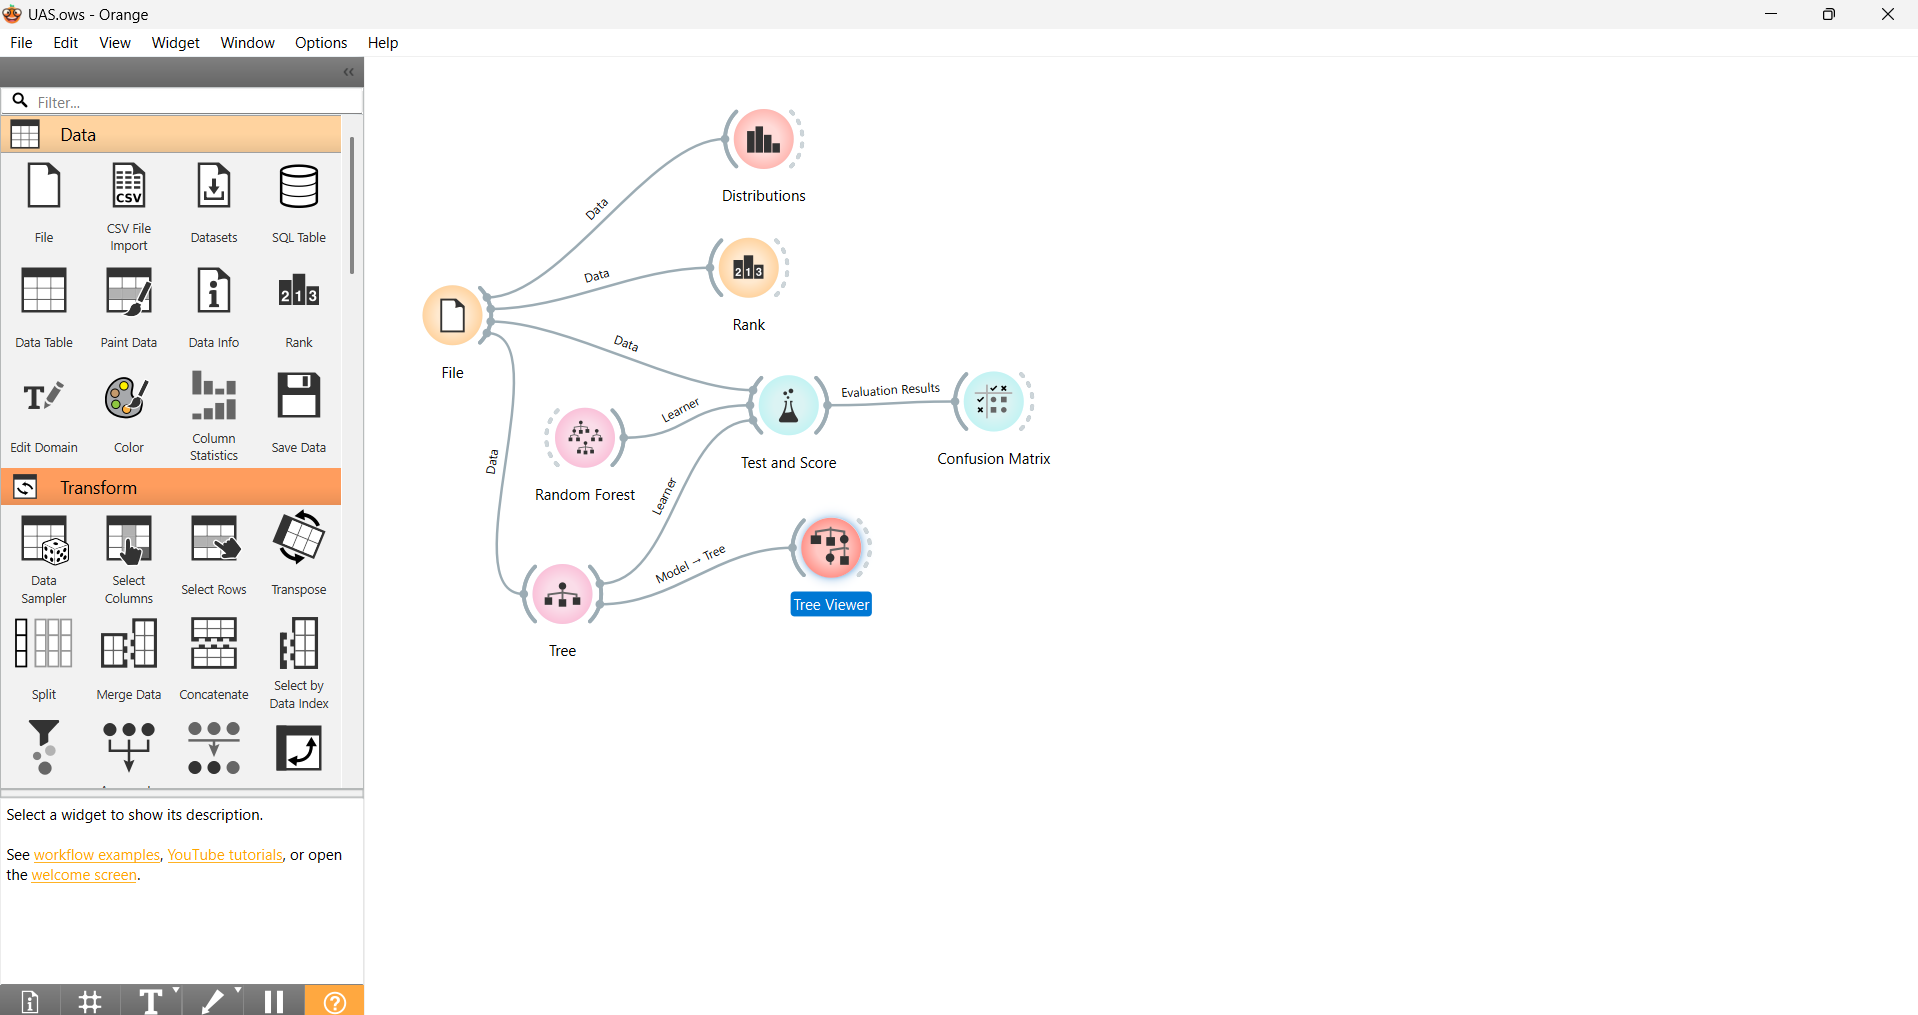

Alur kerja di atas menunjukkan proses *End-to-End* dari penyiapan data, analisis fitur, hingga evaluasi komparatif antara dua algoritma *Machine Learning*: **Decision Tree** dan **Random Forest**.

## 2. Penyiapan dan Eksplorasi Data
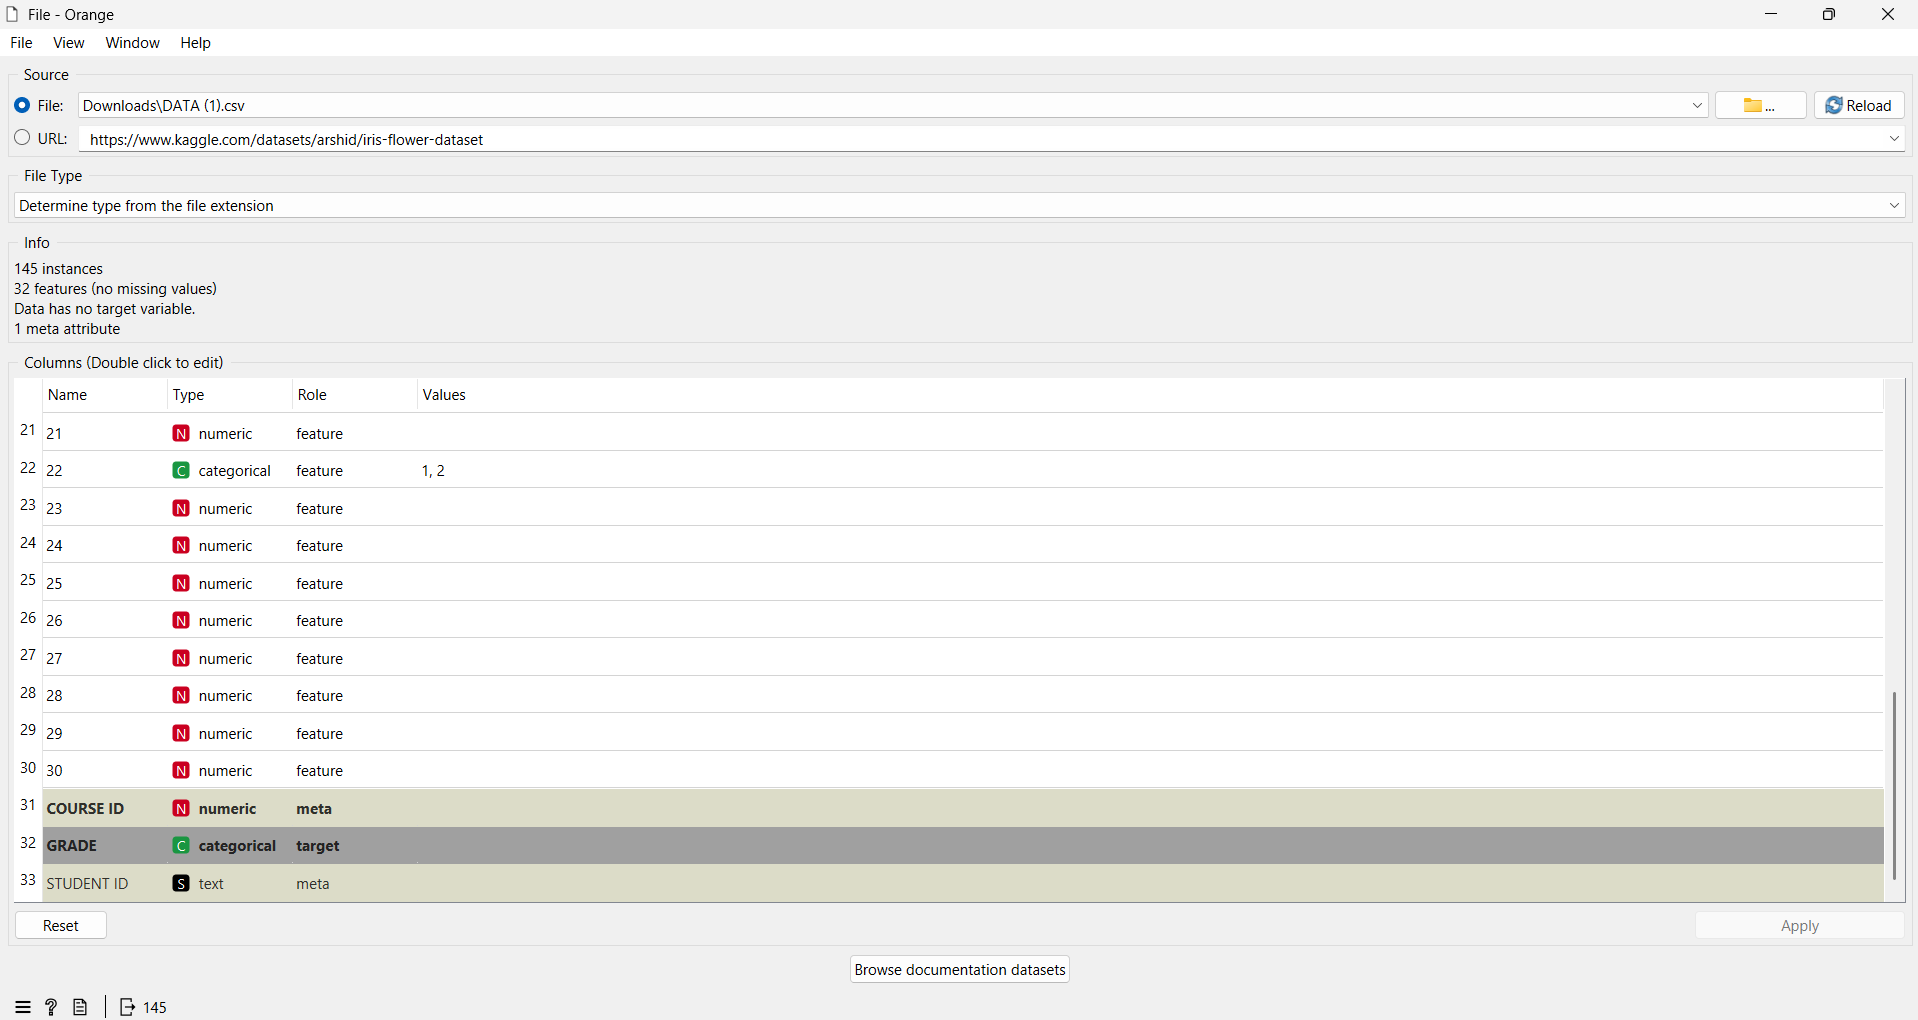

Dataset yang digunakan terdiri dari **145 instance (mahasiswa)** dengan **32 fitur** (pertanyaan kuesioner dan profil). Tidak ditemukan adanya data yang kosong (*no missing values*), sehingga data sudah bersih dan siap diproses. Seluruh fitur kuesioner telah diset sebagai tipe data **Categorical** agar algoritma memprosesnya sebagai kelas (bukan besaran numerik). Kolom `GRADE` ditetapkan sebagai target prediksi.

### Distribusi Kelas Target
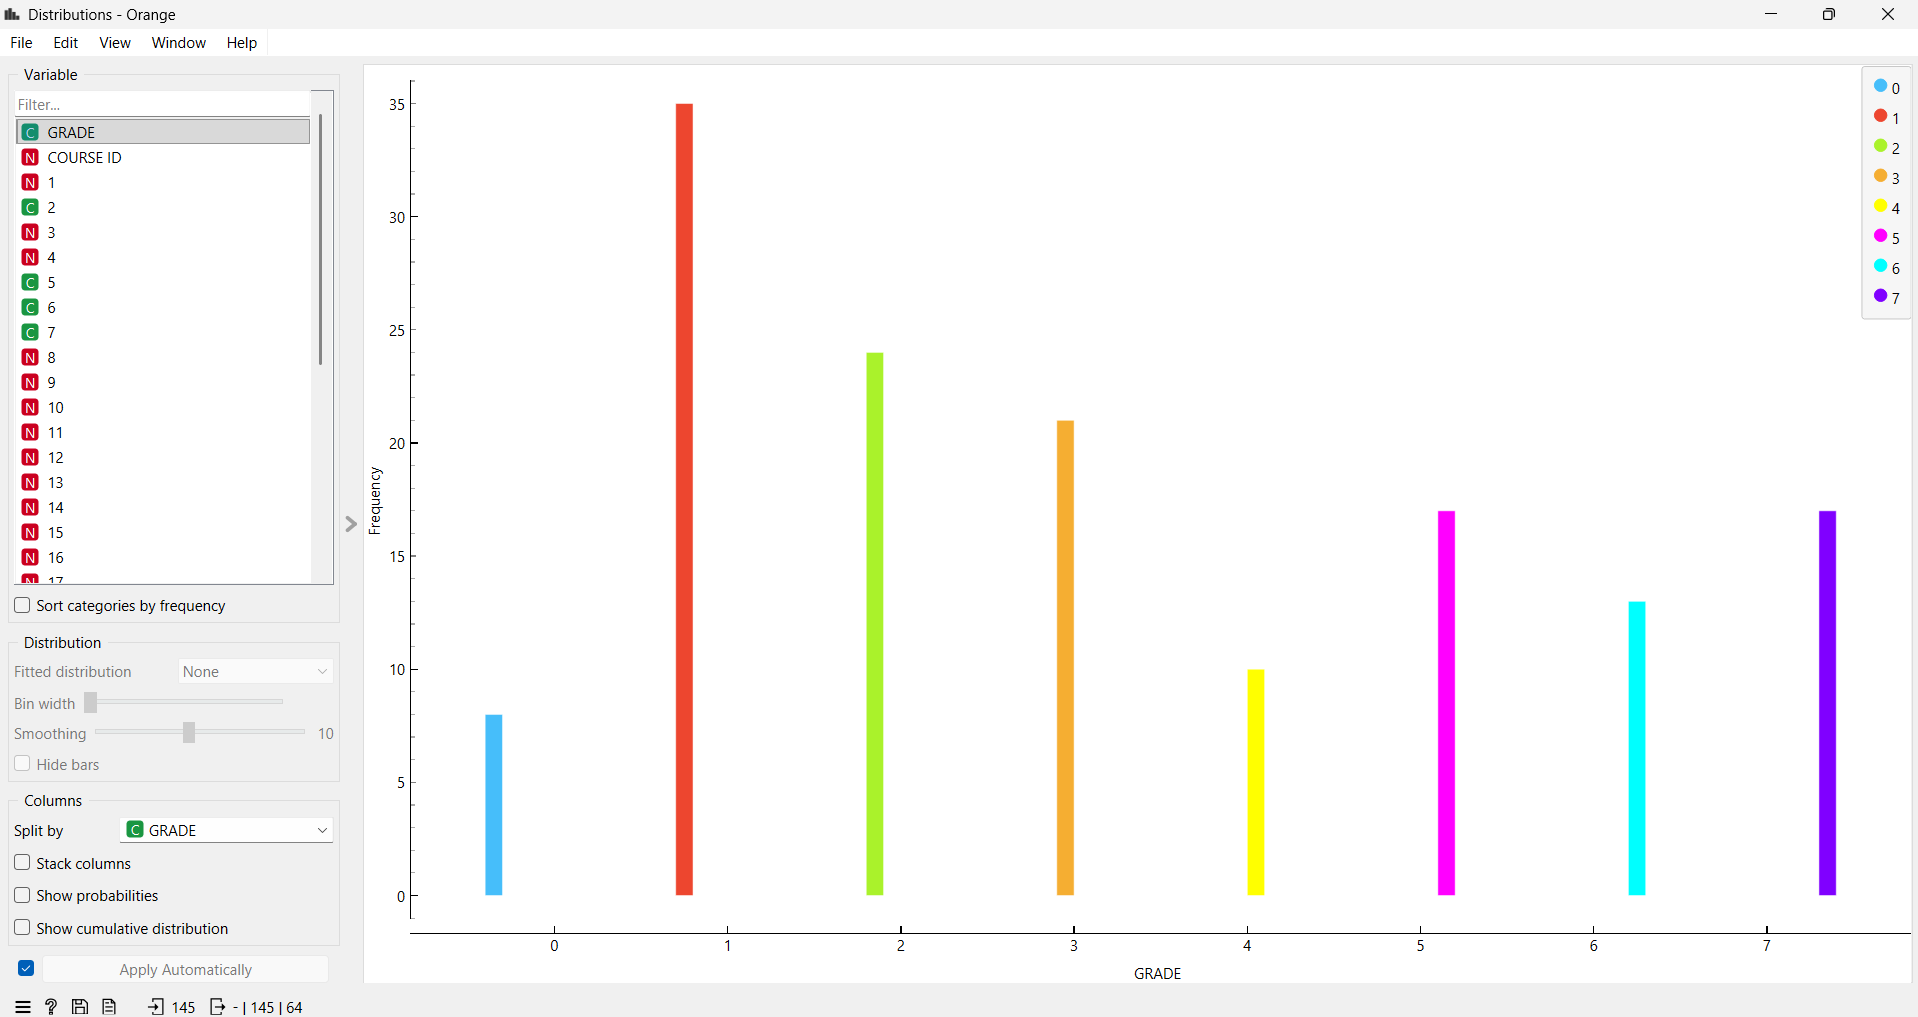

Dari visualisasi distribusi, terlihat bahwa data bersifat tidak seimbang (*imbalanced*). Kelompok mayoritas berada pada prediksi Grade 1 (35 mahasiswa), sementara Grade 0 memiliki jumlah mahasiswa paling sedikit (8 mahasiswa). Ketidakseimbangan ini menjadi tantangan alami dalam pemodelan data rekam jejak manusia.

## 3. Pengaturan Parameter Model
Untuk mencegah terjadinya *overfitting* (model terlalu menghafal data), parameter pembatasan pertumbuhan pohon diterapkan pada kedua algoritma.

*   **Decision Tree:**

    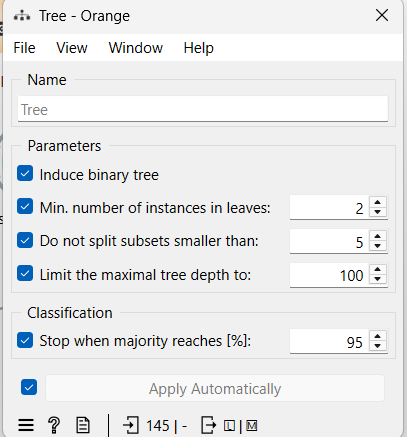
    Minimal *instance* pada daun (*leaves*) diatur sebanyak 2, dan model tidak akan memecah cabang jika datanya kurang dari 5.
*   **Random Forest:**

    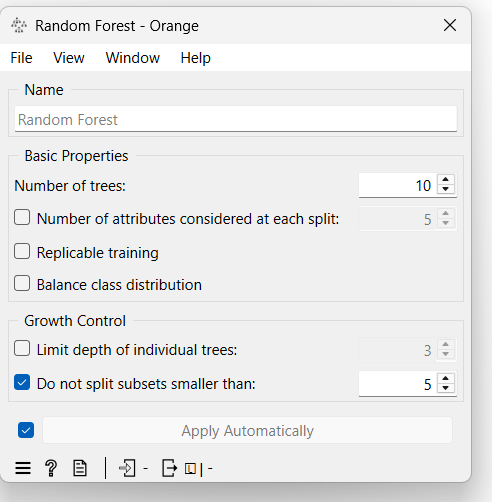
    Menggunakan *ensemble* sebanyak 10 pohon keputusan untuk mengambil suara terbanyak (*majority vote*), dengan batasan *split* terkecil pada angka 5.

## 4. Evaluasi dan Komparasi Performa
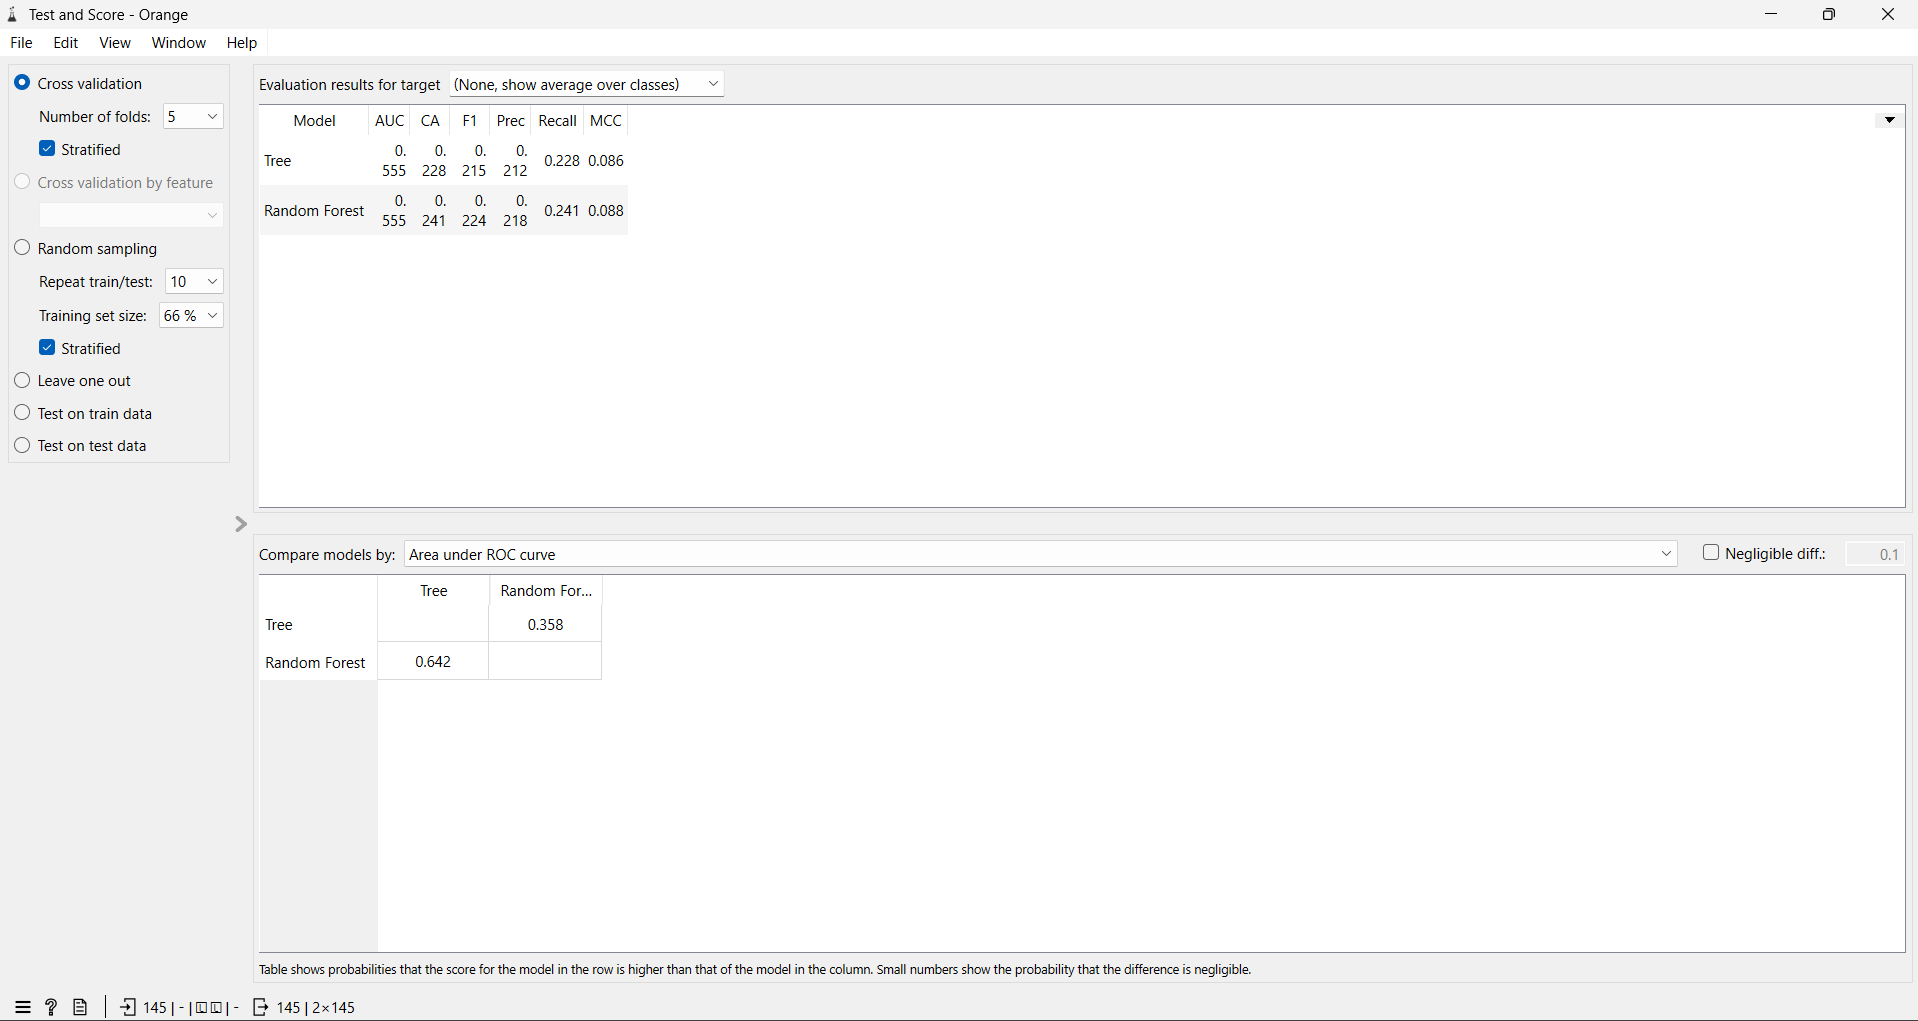

Pengujian dilakukan menggunakan metode **5-fold Cross Validation**. Hasil komparasi menunjukkan bahwa **Random Forest sedikit lebih unggul** dengan nilai Akurasi (*Classification Accuracy / CA*) sebesar **0.241**, dibandingkan Decision Tree yang mendapat nilai **0.228**.

### Analisis Kesalahan (Confusion Matrix)

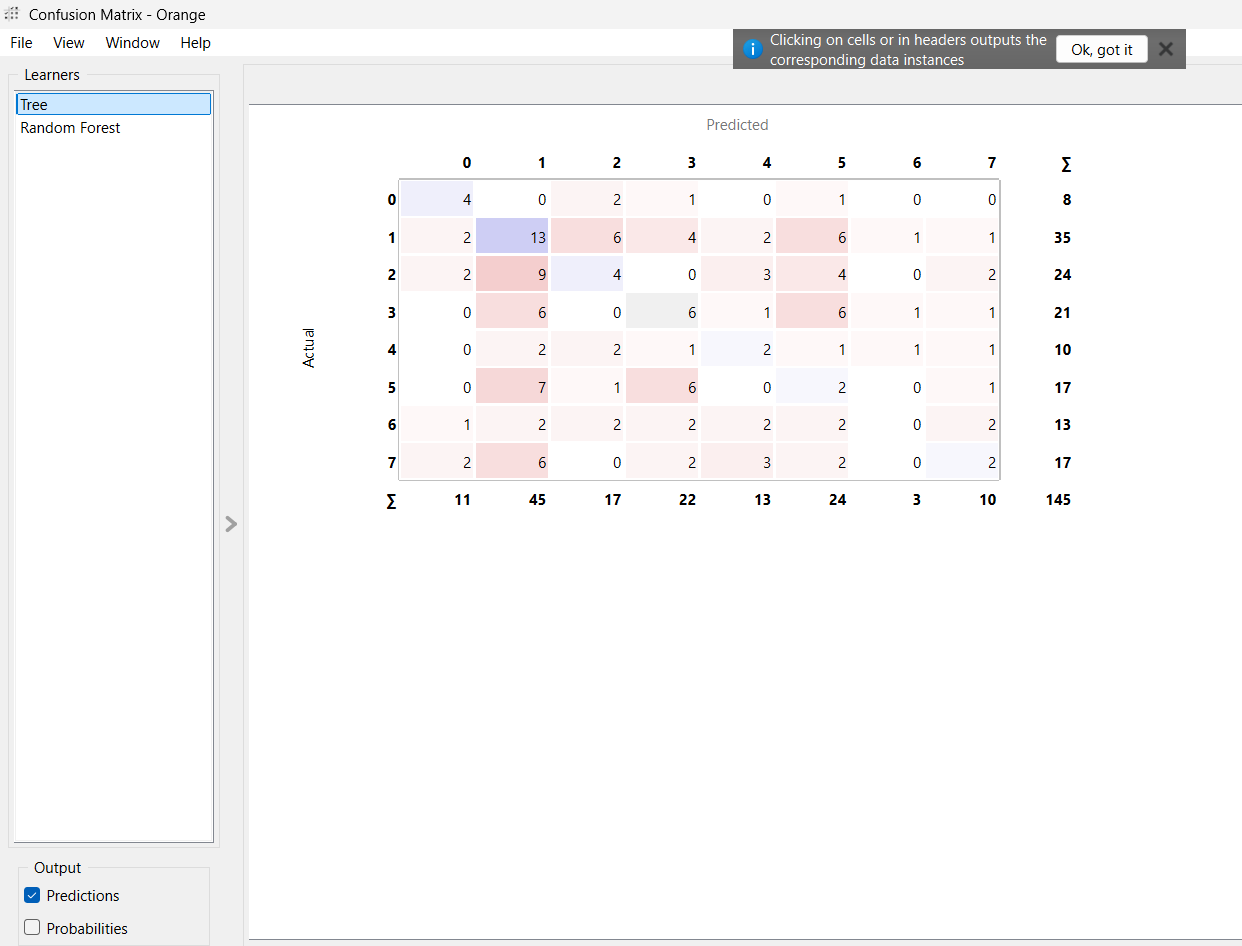


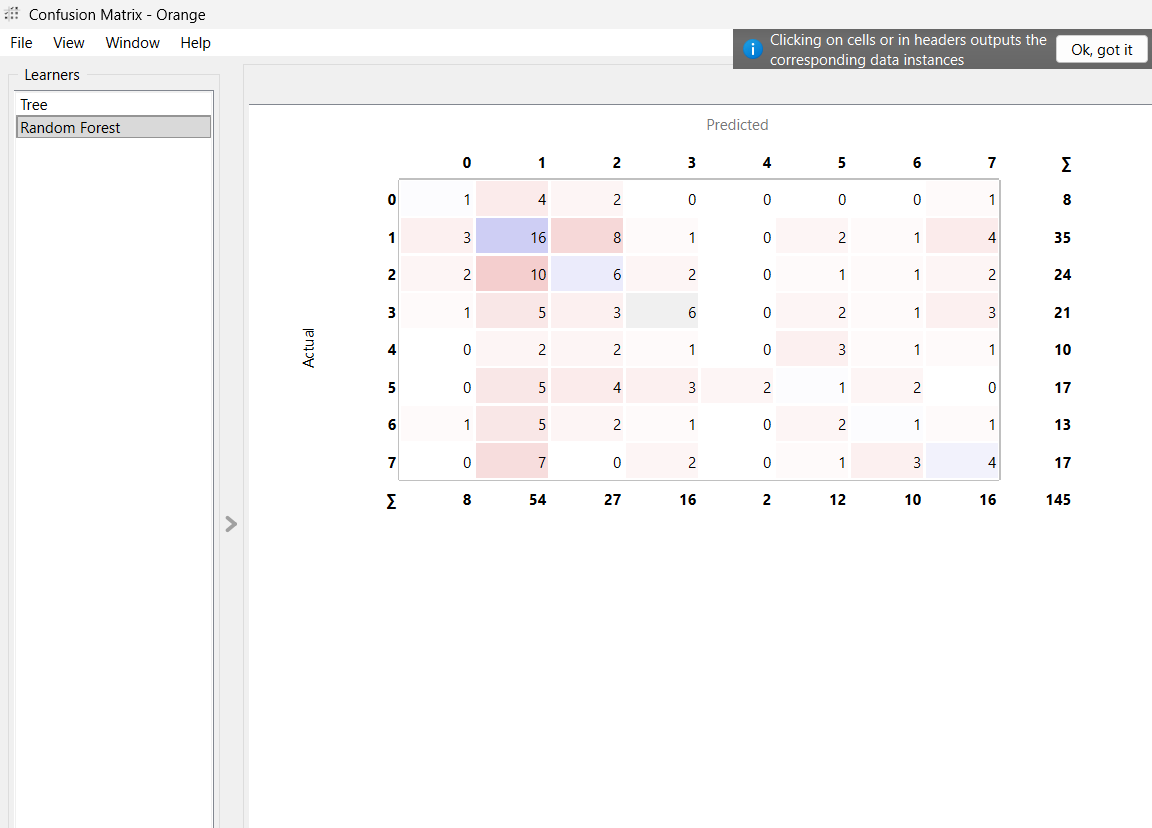

*Confusion Matrix* di atas membuktikan kenapa skor CA Random Forest lebih tinggi dari Decision Tree:
*   Pada algoritma **Decision Tree**, ketika nilai mahasiswa aslinya adalah kelas '1', model berhasil menebak benar sebanyak **13 kali**.
*   Sedangkan pada algoritma **Random Forest**, tebakan benar untuk kelas '1' meningkat menjadi **16 kali**. Penggabungan 10 pohon di Random Forest terbukti mampu mengurangi kebingungan (*confusion*) model dalam memprediksi kelas mayoritas.

## 5. Ekstraksi Wawasan (Knowledge Extraction) dari Decision Tree
Kelebihan mutlak dari Decision Tree dibandingkan Random Forest adalah kemampuannya menghasilkan visualisasi sebab-akibat yang dapat dibaca manusia secara langsung.

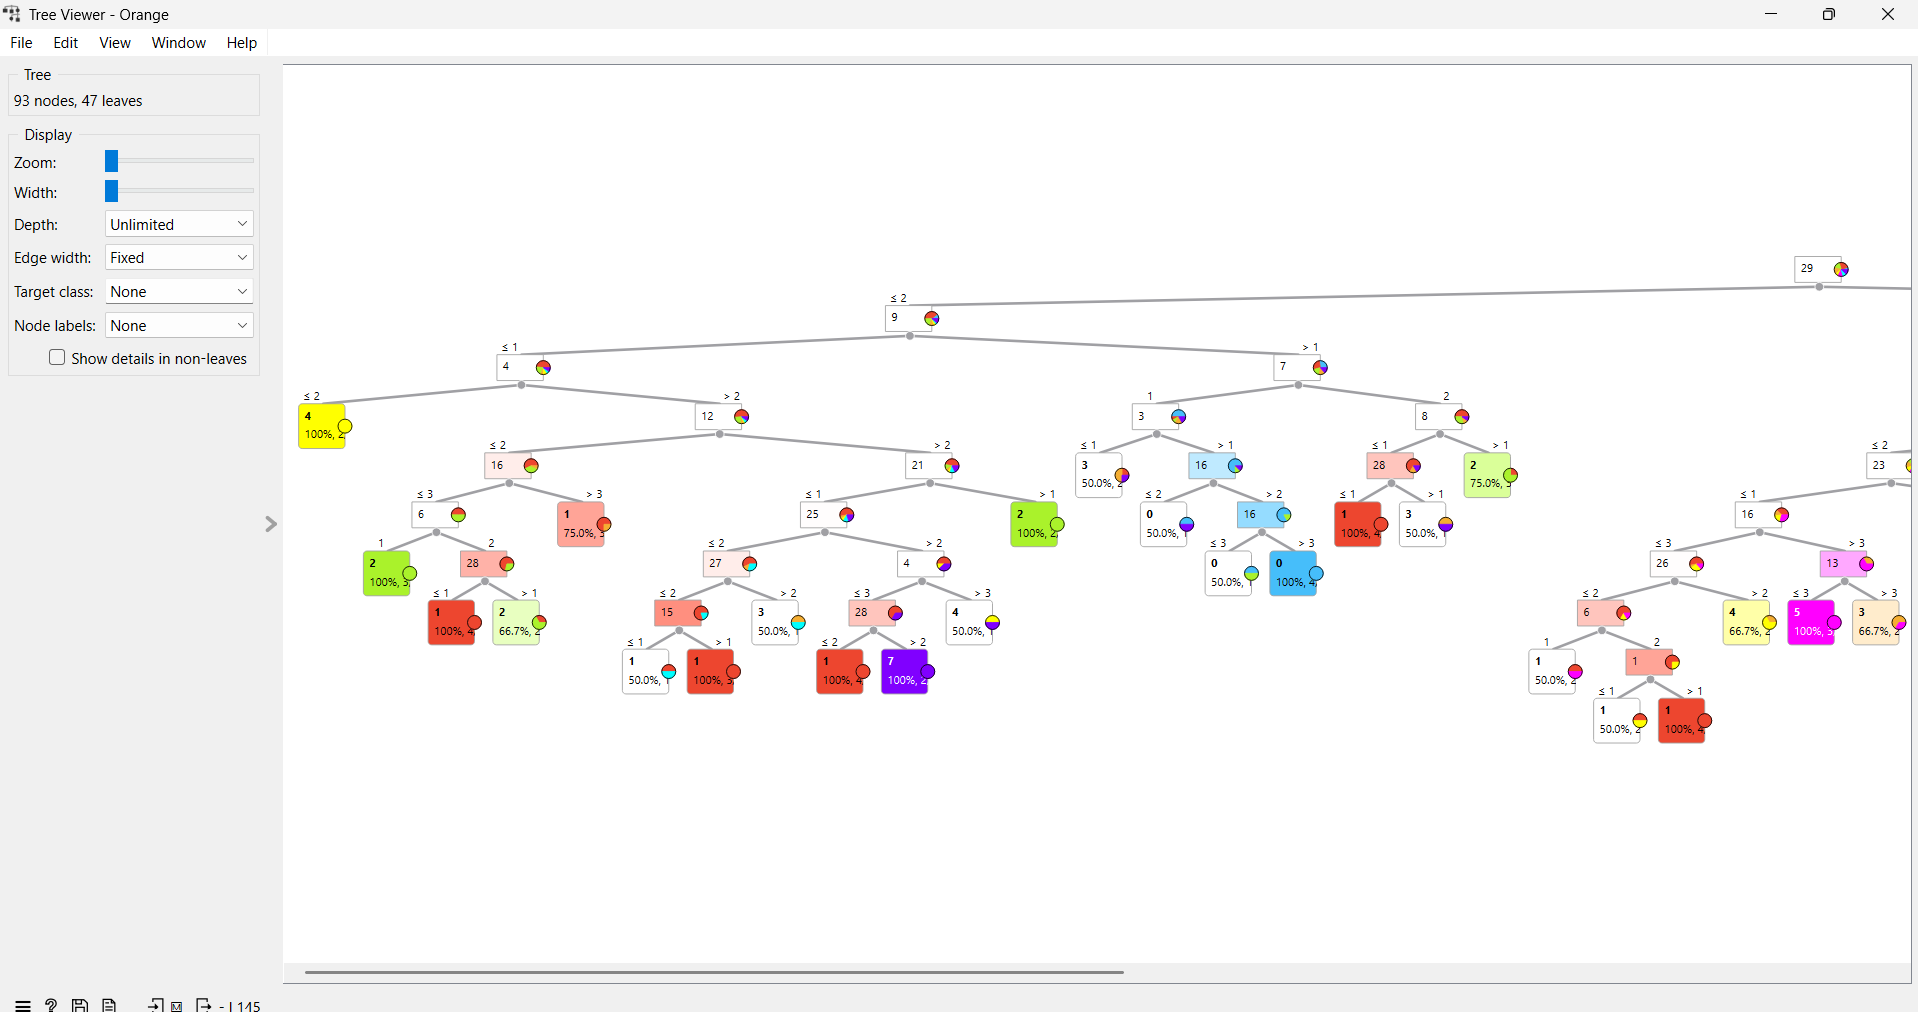

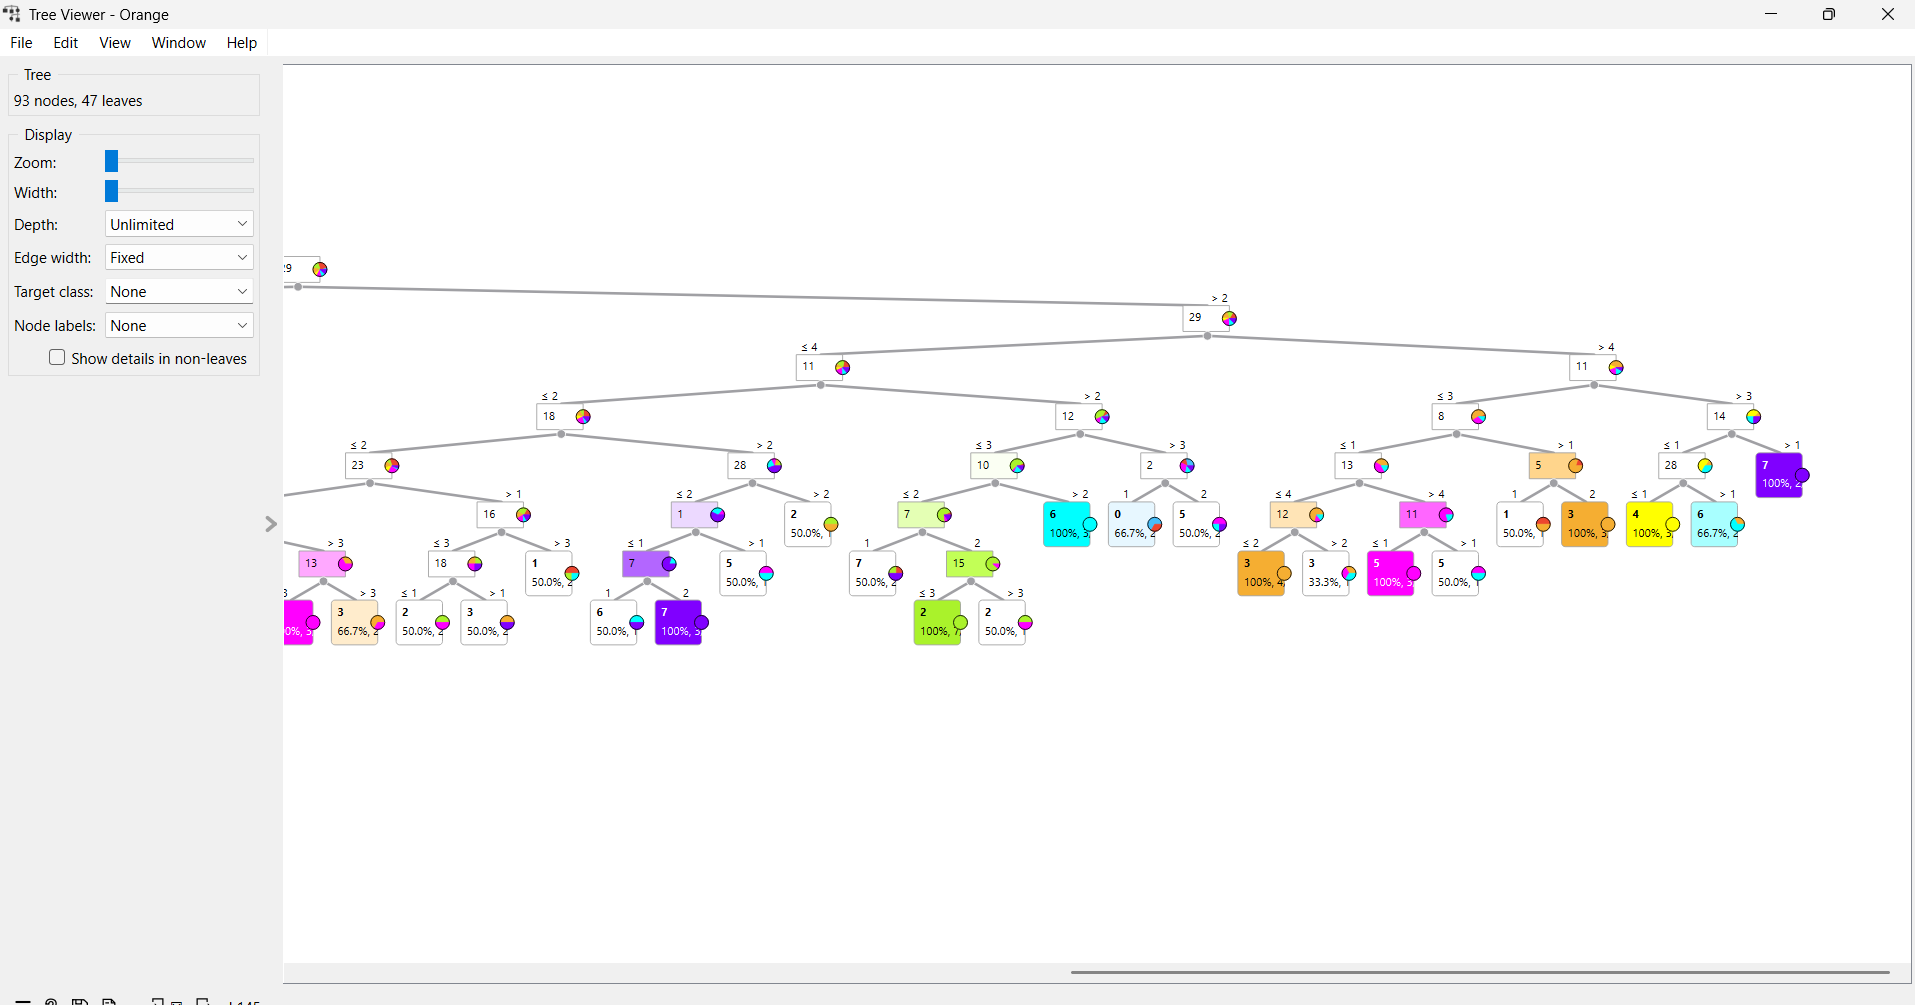

Berdasarkan *Decision Tree* yang terbentuk, kita dapat menarik wawasan (*insight*) spesifik terkait kondisi mahasiswa. Berikut adalah beberapa contoh aturan (*Rules*) yang berhasil diekstrak:

**Kasus A: Prediksi Grade 4 (Intervensi Dini)**
*   **Kondisi:** Jika mahasiswa memiliki IPK $\le$ 2.49 (Atribut 29), pergi ke kampus menggunakan bus (Atribut 9), dan tidak memiliki beasiswa atau maksimal 25% (Atribut 4).
*   **Hasil:** Terdapat 2 mahasiswa dengan kondisi ini dan seluruhnya (100%) diprediksi masuk ke dalam **Grade 4** (daun berwarna kuning di paling kiri).

**Kasus B: Prediksi Grade 7 (Prestasi Maksimal)**
*   **Kondisi:** IPK awal $\le$ 2.49, menggunakan bus, namun memiliki beasiswa tepat 50%, didukung pendidikan ayah minimal SMA, merasakan dampak positif dari proyek kampus, rajin mencatat di kelas, dan metode *flipped classroom* tidak diterapkan.
*   **Hasil:** Terdapat 2 anak dengan rekam jejak persis seperti ini, dan keduanya (100%) sukses membalikkan keadaan menjadi **Grade 7** (daun ungu).